## Student Permormance Indicator

### Life cycle of machine learning Project

- Understanding the problem statement 
- Data collection
- Understanding the data
- Performing EDA
- Data preprocessing
- model training
- Choosing the best model

### 1) Problem statement

- This project aims to understand how the performance score of students is affected by various factors such as gender, ethinicity, parental level of education, lunch, Test preparation course 

### 2) Data collection

- Dataset source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 columns and 1000 rows

### 2.1 Import data and required packages

Importing numpy, pandas, matplotlib, seaborn and warnings library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

Import CSV data as pandas dataframe

In [2]:
df = pd.read_csv("data\StudentsPerformance.csv")

Show top 5 rows

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape of the dataset

In [4]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced)
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3) Data checks to perform

- Checking missing values
- Checking for duplicate valuess
- check datatypes
- check the number of unique values of each column
- check statistic of the dataset
- check various categories present in categorical column

### 3.1 Check missing values

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There is no missing values in the dataset

### 3.2 Check duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

There is no duplicate values

### 3.3 Check datatypes

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Check number of uniques values in each column

In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 Check statistics of the dataset

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight

- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.6 Check various categories present in categorical column

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
print("Categories present in 'gender' variable                          ", df['gender'].unique().tolist())
print("Categories present in 'race/ethnicity' variable                  ", df['race/ethnicity'].unique().tolist())
print("Categories present in 'parental level of education' variable     ", df['parental level of education'].unique().tolist())
print("Categories present in 'lunch' variable                           ", df['lunch'].unique().tolist())
print("Categories present in 'test preparation course' variable         ", df['test preparation course'].unique().tolist())

Categories present in 'gender' variable                           ['female', 'male']
Categories present in 'race/ethnicity' variable                   ['group B', 'group C', 'group A', 'group D', 'group E']
Categories present in 'parental level of education' variable      ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories present in 'lunch' variable                            ['standard', 'free/reduced']
Categories present in 'test preparation course' variable          ['none', 'completed']


Defining categorical and numerical columns

In [12]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'string']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'string']

print("We have {} numerical features namely: {}".format(len(numerical_features), numerical_features))
print("We have {} categorical features namely: {}".format(len(categorical_features), categorical_features))

We have 3 numerical features namely: ['math score', 'reading score', 'writing score']
We have 5 categorical features namely: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


Adding columns for "total score" and "average"

In [13]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


Students with full marks (100)

In [14]:
math_full = (df['math score'] == 100).sum()
writing_full = (df['writing score'] == 100).sum()
reading_full = (df['reading score'] == 100).sum()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')


Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


Students with less than or equal to 20 marks

In [15]:
math_less_20 = (df['math score'] <= 20).sum()
writing_less_20 = (df['writing score'] <= 20).sum()
reading_less_20 = (df['reading score'] <= 20).sum()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


Insights

- From above values we get students have performed the worst in Maths
- Best performance is in reading section

### 4. Exploring data (Visualization)

#### 4.1 Vizualize average score distribution to make some conclusions

- Histogram
- KDE

#### 4.1.1 Histogram and KDE

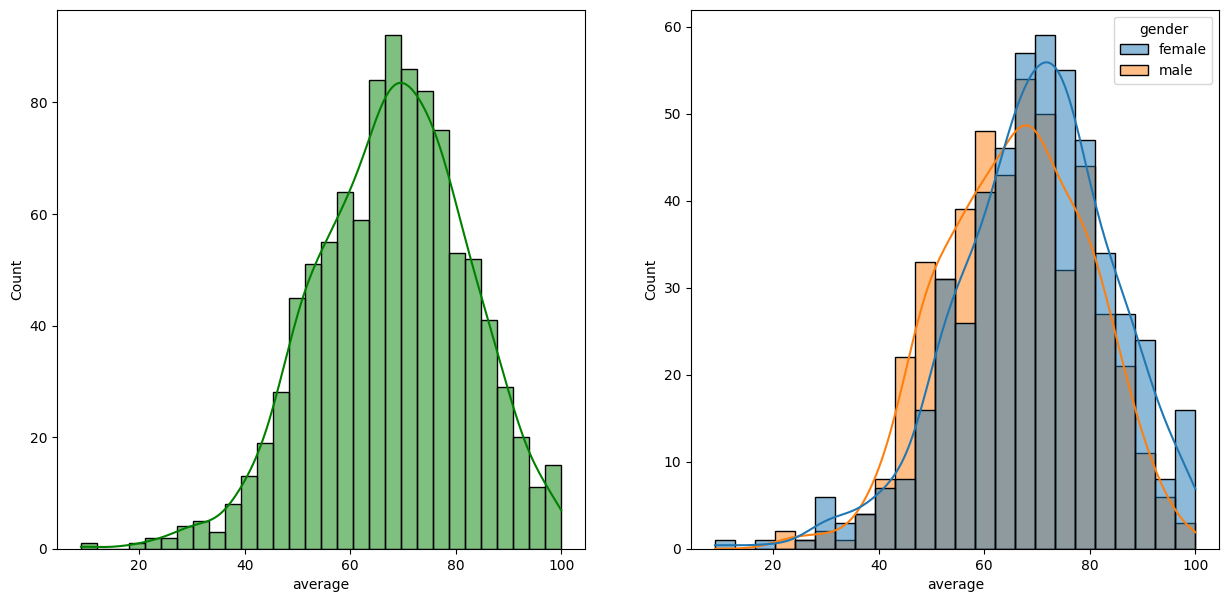

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
sns.histplot(data=df, x='average', bins=30, kde=True, color='g', ax=axs[0])
sns.histplot(data=df, x='average', kde=True, hue='gender', ax=axs[1])
plt.show()

Insights

- Female student tends to perform better than male students

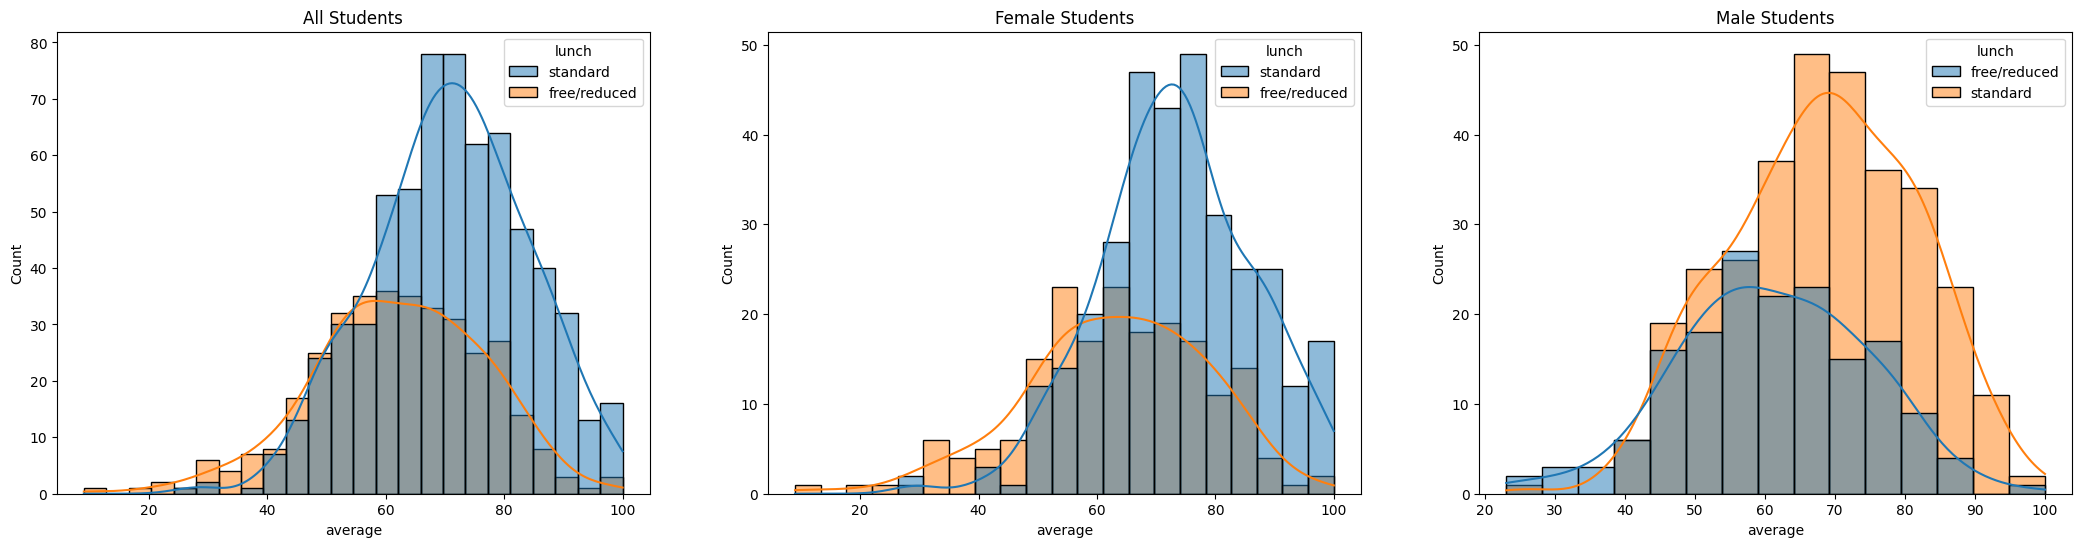

In [17]:
fig, axs = plt.subplots(1,3, figsize=(26,6))
sns.histplot(data=df, x='average', kde=True, hue='lunch', ax=axs[0])
axs[0].set_title("All Students")
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='lunch', ax=axs[1])
axs[1].set_title("Female Students")
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='lunch', ax=axs[2])
axs[2].set_title("Male Students")
plt.show()

Insights

- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

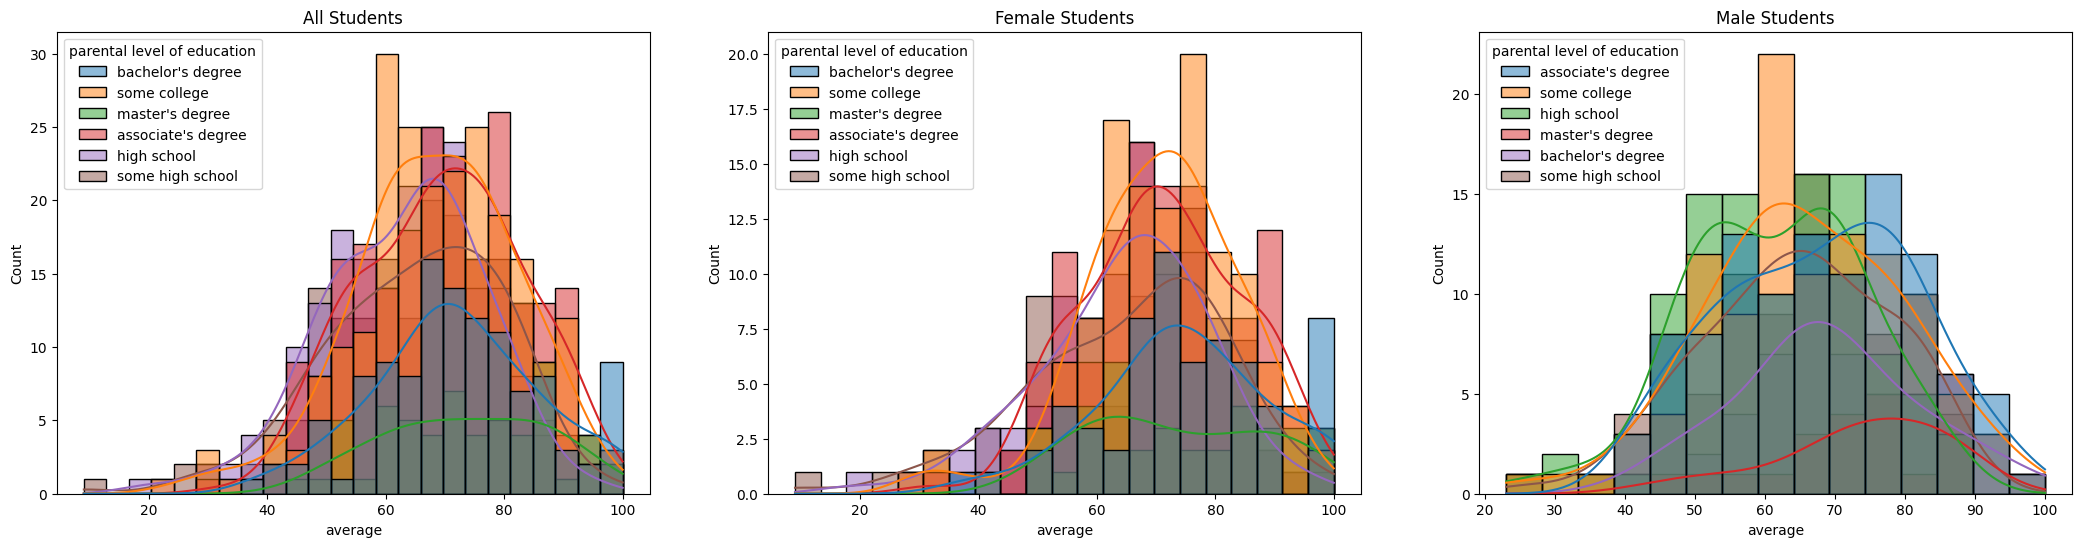

In [18]:
fig, axs = plt.subplots(1,3, figsize=(26,6))
sns.histplot(data=df, x='average', kde=True, hue='parental level of education', ax=axs[0])
axs[0].set_title("All Students")
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='parental level of education', ax=axs[1])
axs[1].set_title("Female Students")
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='parental level of education', ax=axs[2])
axs[2].set_title("Male Students")
plt.show()


Insights

1. Parent's education has a weak effect overall — all groups cluster in the same 60–80 range, but the difference is not dramatic enough to call it a strong predictor.

2. For male students, the effect of parent's education is slightly more visible — some groups do shift higher — but the insight as written is unreliable because the legend order changes between plots, making it easy to misread which color belongs to which education level.

3. For female students, all education level groups overlap almost completely — the distributions are nearly identical in shape and position, so parent's education genuinely has little to no effect on female student scores.

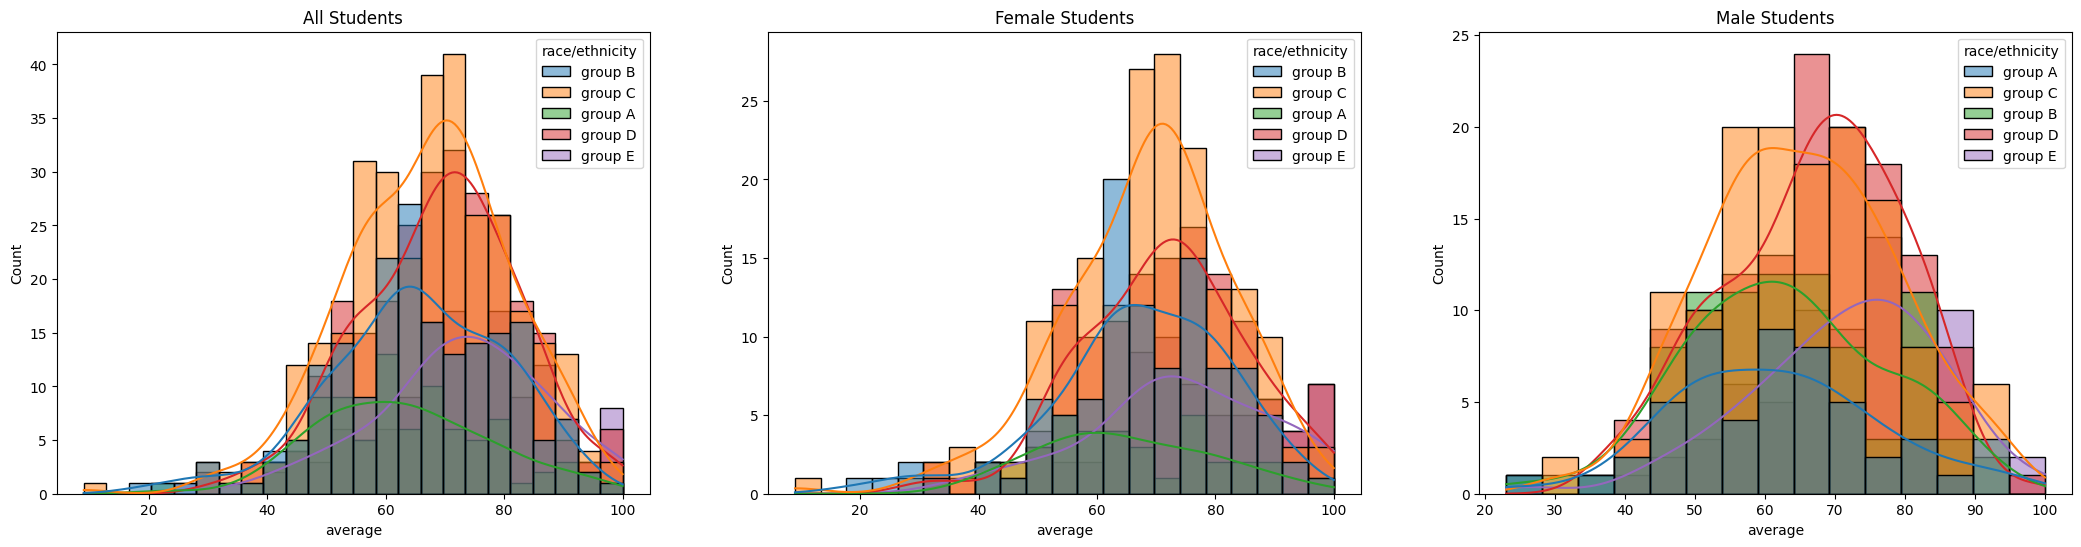

In [19]:
fig, axs = plt.subplots(1,3, figsize=(26,6))
sns.histplot(data=df, x='average', kde=True, hue='race/ethnicity', ax=axs[0])
axs[0].set_title("All Students")
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='race/ethnicity', ax=axs[1])
axs[1].set_title("Female Students")
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='race/ethnicity', ax=axs[2])
axs[2].set_title("Male Students")
plt.show()

Insights:

- Group C and D dominate in count across all three plots — their bars are tallest — which matches what we saw earlier in the pie chart. Group A and E are smallest in count.
- Looking at where each group's KDE curve peaks: Group A and B peak earlier (around 55–65), while Group D and E peak later (around 70–80). This means students from Group E and D tend to score higher on average — consistent across both male and female plots.
- The pattern holds for both genders — in both the Female and Male plots, the same groups (A, B) are shifted left and the same groups (D, E) are shifted right. So race/ethnicity affects scores regardless of gender.

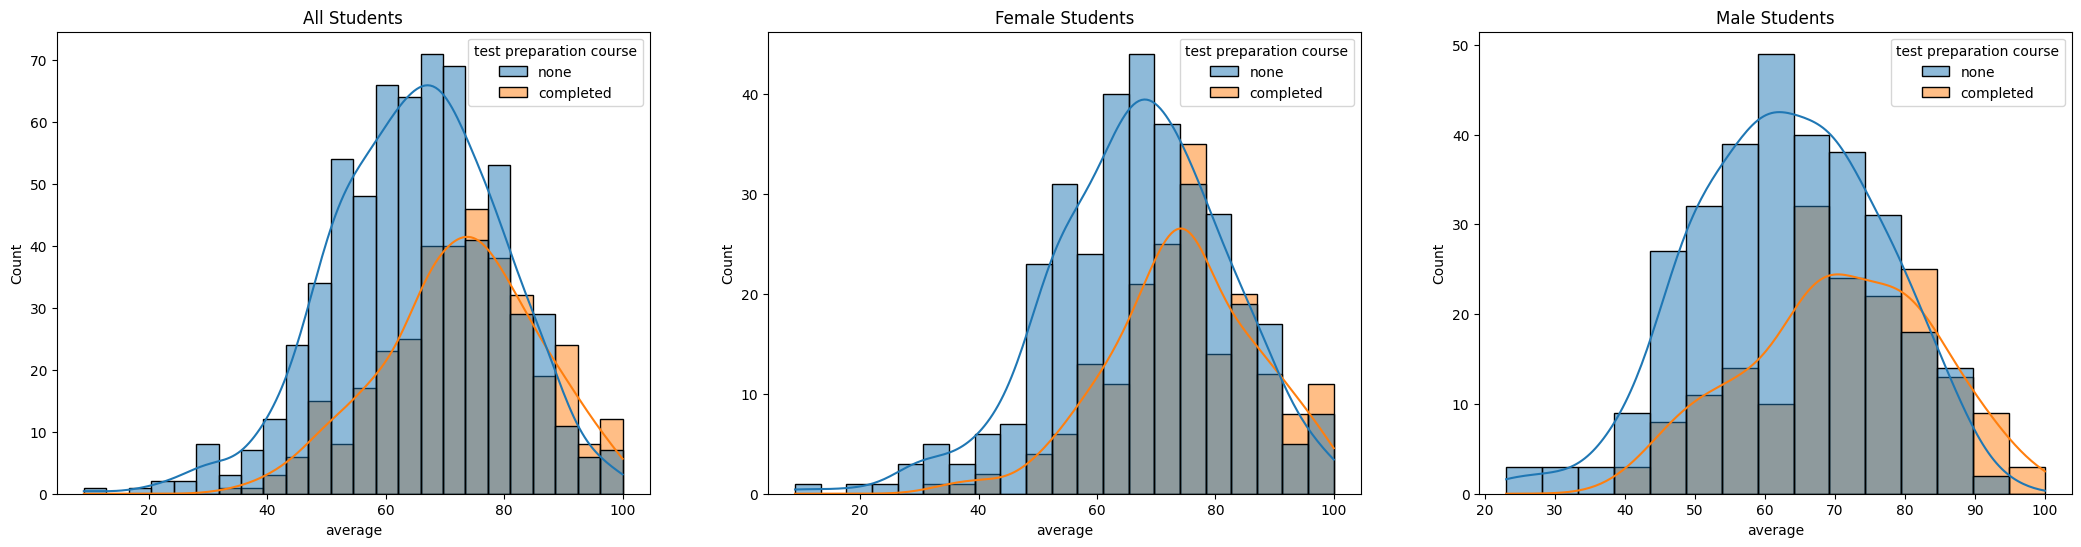

In [20]:
fig, axs = plt.subplots(1,3, figsize=(26,6))
sns.histplot(data=df, x='average', kde=True, hue='test preparation course', ax=axs[0])
axs[0].set_title("All Students")
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='test preparation course', ax=axs[1])
axs[1].set_title("Female Students")
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='test preparation course', ax=axs[2])
axs[2].set_title("Male Students")
plt.show()

In [21]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### 4.2 Score Distribution Across All Three Subjects

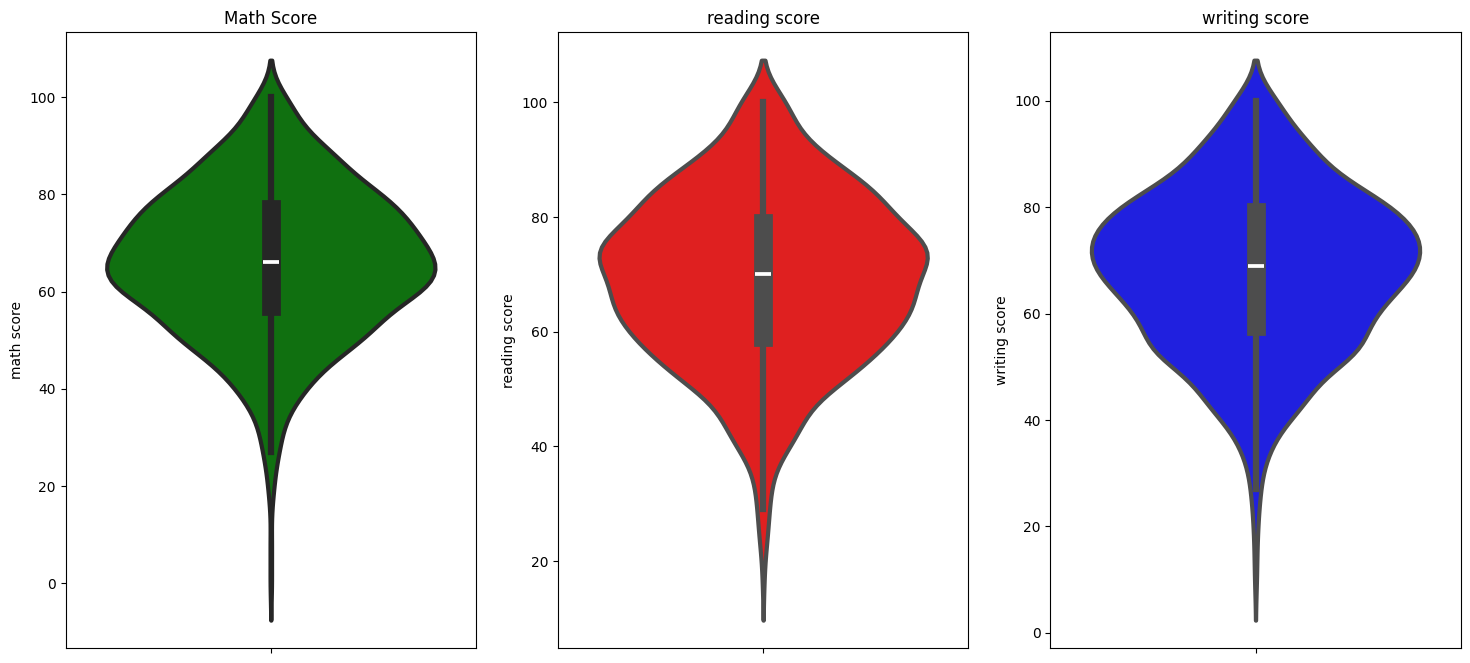

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(18,8))
sns.violinplot(y='math score', data=df, color='green', linewidth=3, ax=axs[0])
axs[0].set_title("Math Score")
sns.violinplot(y='reading score', data=df, color='red', linewidth=3, ax=axs[1])
axs[1].set_title("reading score")
sns.violinplot(y='writing score', data=df, color='blue', linewidth=3, ax=axs[2])
axs[2].set_title("writing score")
plt.show()

- All three subjects have their bulk in the 55–80 range - consistent with what we saw in histplots
- Math has the most extreme low outliers (tail reaching 0) - a few students really struggle with math specifically
- Reading and writing are very similar to each other in shape, suggesting students who are good at one tend to be good at the other
- The section title says "maximum score" but what the plot actually shows is the full distribution - the insight should really be about where scores concentrate, not just the maximum

### 4.3 Five univariate pie charts

In [23]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [24]:
df['test preparation course'].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

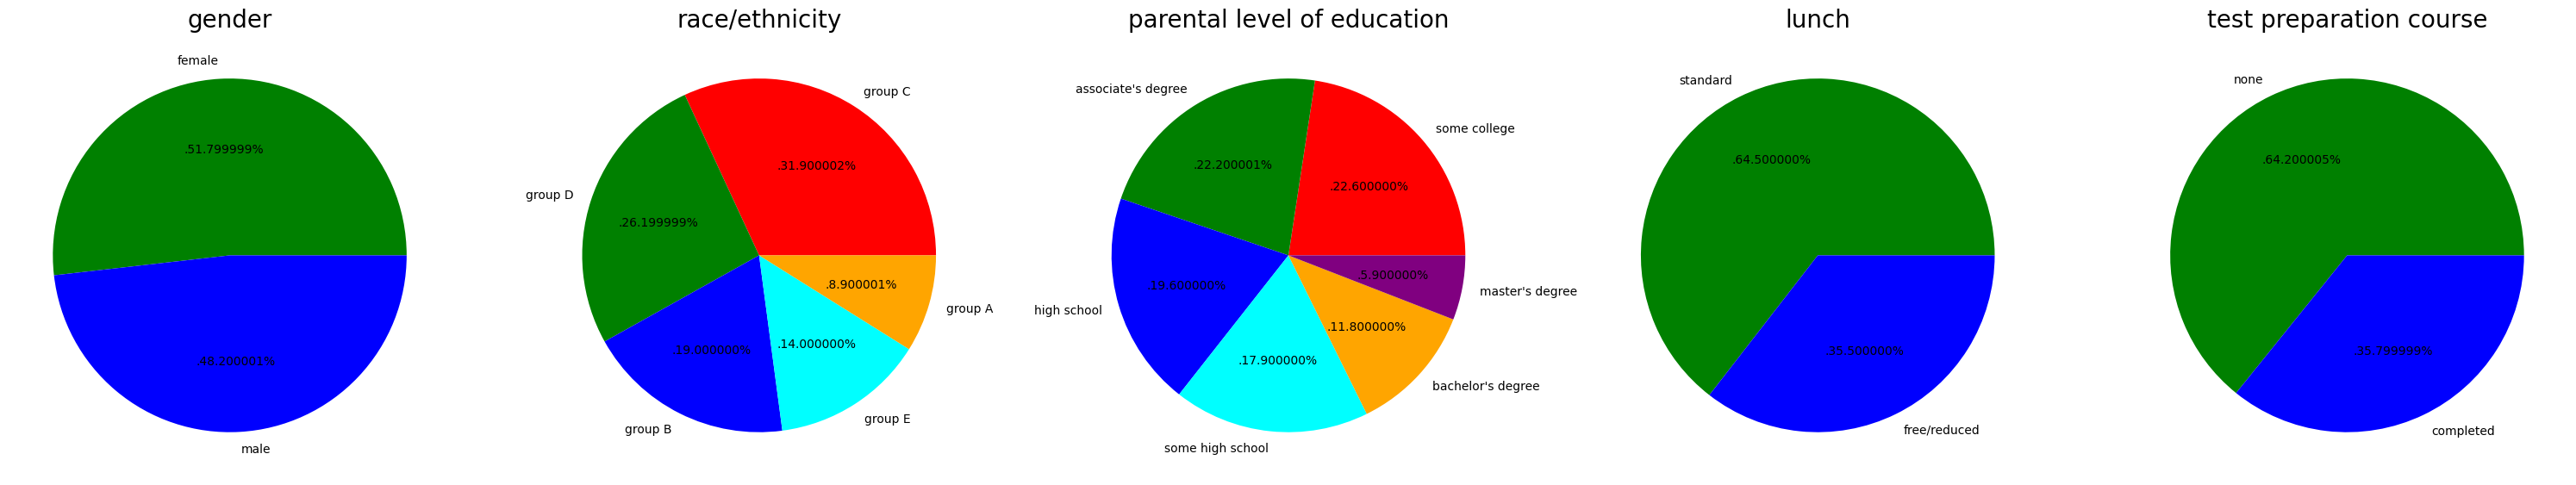

In [25]:
fig, axs = plt.subplots(1,5, figsize=(30,12))

#gender
size = df['gender'].value_counts()
axs[0].pie(size, colors=['green', 'blue'], labels=['female', 'male'], autopct='.%2f%%')
axs[0].set_title("gender", fontsize=20)
axs[0].axis('off')

#race/ethnicity
size = df['race/ethnicity'].value_counts()
axs[1].pie(size, colors=['red','green','blue','cyan','orange'], labels=['group C','group D','group B','group E','group A'], autopct='.%2f%%')
axs[1].set_title("race/ethnicity", fontsize=20)
axs[1].axis('off')

#parental level of education
size = df['parental level of education'].value_counts()
axs[2].pie(size, colors=['red','green','blue','cyan','orange','purple'], labels=["some college","associate's degree","high school","some high school","bachelor's degree","master's degree"], autopct='.%2f%%')
axs[2].set_title("parental level of education", fontsize=20)
axs[2].axis('off')

#lunch
size = df['lunch'].value_counts()
axs[3].pie(size, colors=['green', 'blue'], labels=['standard', 'free/reduced'], autopct='.%2f%%')
axs[3].set_title("lunch", fontsize=20)
axs[3].axis('off')

#test preparation course
size = df['test preparation course'].value_counts()
axs[4].pie(size, colors=['green', 'blue'], labels=['none', 'completed'], autopct='.%2f%%')
axs[4].set_title("test preparation course", fontsize=20)
axs[4].axis('off')

plt.tight_layout()
plt.show()

Insights
- **Gender:** Nearly equal — 52% male, 48% female.
- **Race/Ethnicity:** Group C dominates at 32%, Group A is the smallest at 9%.
- **Parental Education:** Some College and Associate's Degree together make up ~45%, Master's Degree is the rarest at 6%.
- **Lunch:** 2:1 ratio — 64% standard, 36% free/reduced.
- **Test Prep:** Same 64/36 split as lunch — majority never completed the course.

In [26]:
gender_group = df.groupby('gender').mean(numeric_only=True)
print(gender_group[['math score', 'reading score', 'writing score', 'average']])

        math score  reading score  writing score    average
gender                                                     
female   63.633205      72.608108      72.467181  69.569498
male     68.728216      65.473029      63.311203  65.837483


### 4.4 Feature Wise Visualization

#### 4.4.1 GENDER COLUMN

- Is gender has any impact on student's performance ?

BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [34]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


In [39]:
data = pd.DataFrame({
    'categories': ['Total average', 'Total average', 'Math score', 'Math score'],
    'gender': ['female', 'male', 'female', 'male'],
    'score': [gender_group['average']['female'],
              gender_group['average']['male'],
              gender_group['math score']['female'],
              gender_group['math score']['male']]
})

In [40]:
data.head()

,categories,gender,score
0,Total average,female,69.569498
1,Total average,male,65.837483
2,Math score,female,63.633205
3,Math score,male,68.728216


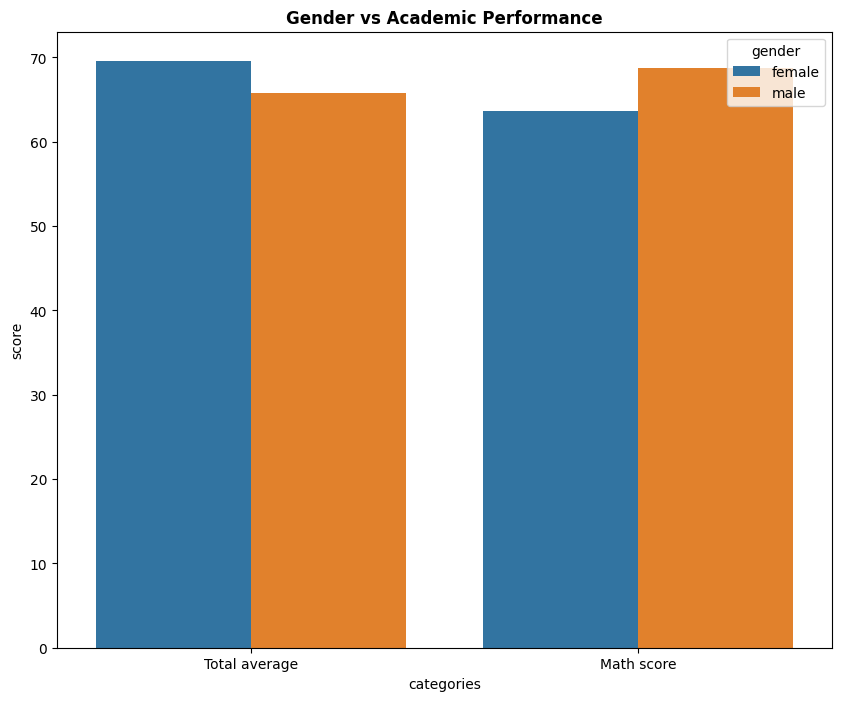

In [43]:
fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(data=data, x='categories', hue='gender', y='score', ax=ax)
ax.set_title("Gender vs Academic Performance", fontweight='bold')
plt.show()

#### 4.4.2 RACE/EHNICITY COLUMN

- Is Race/Ehnicity has any impact on student's performance ?

BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

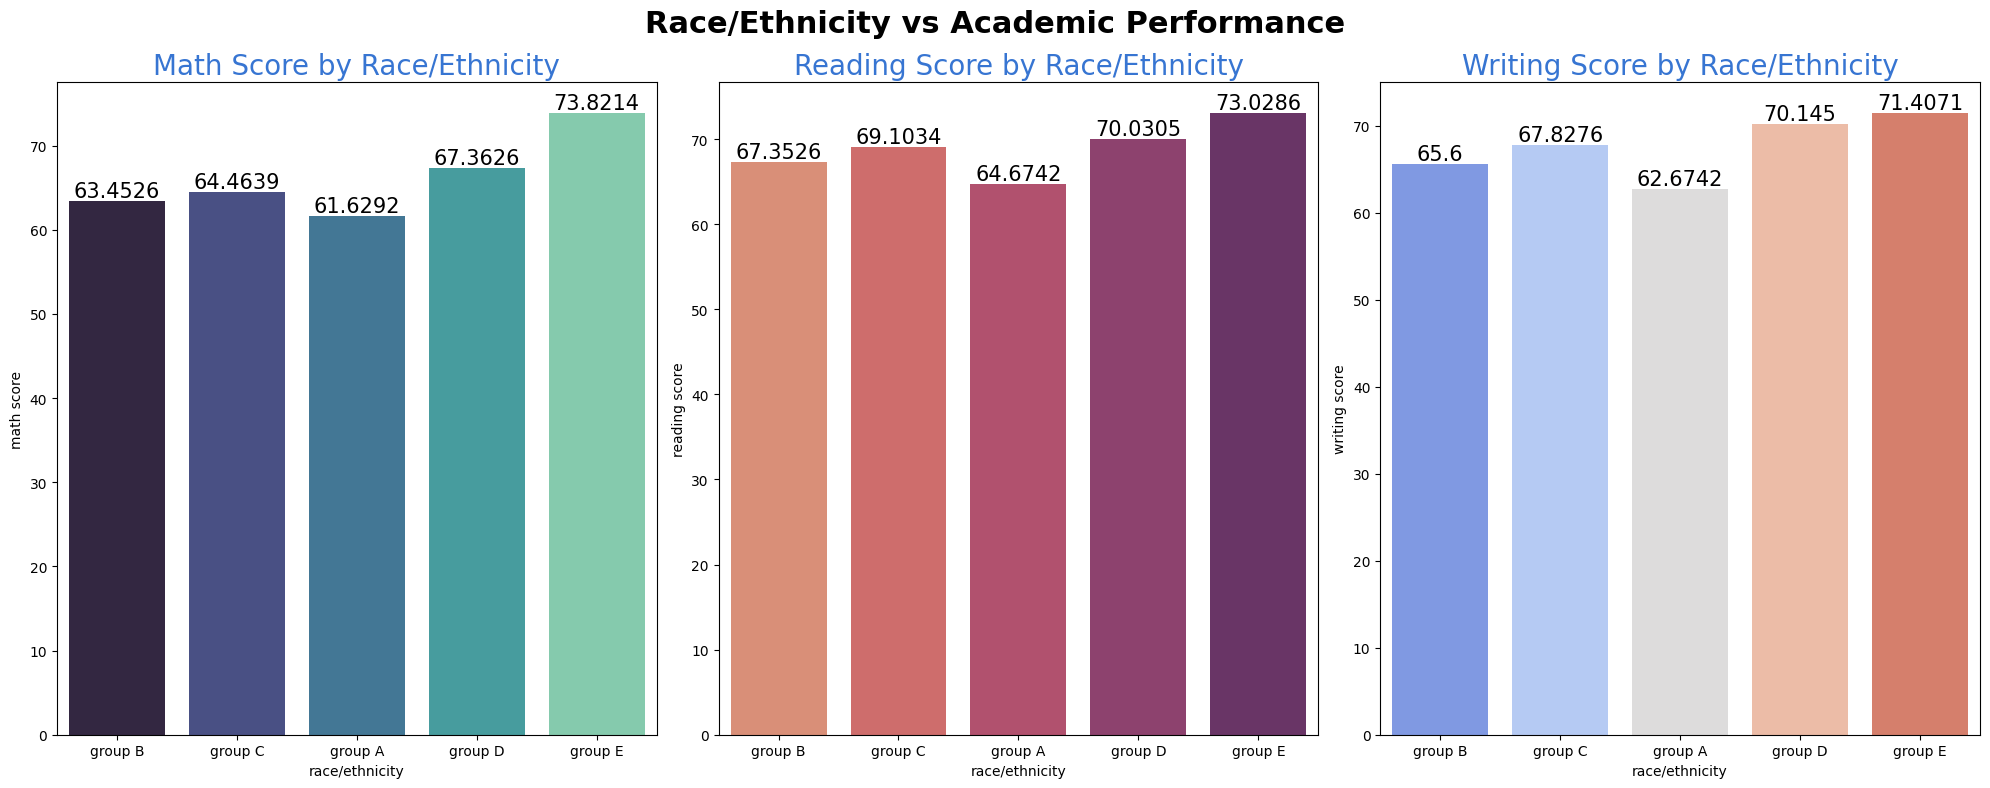

In [72]:
fig, axs = plt.subplots(1,3, figsize=(20,8))

sns.barplot(data=df, x="race/ethnicity", y = "math score", palette='mako', errorbar=None, ax=axs[0])
axs[0].set_title("Math Score by Race/Ethnicity", color="#3775d2", size=20)
for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=15)

sns.barplot(data=df, x="race/ethnicity", y = "reading score", palette='flare', errorbar=None, ax=axs[1])
axs[1].set_title("Reading Score by Race/Ethnicity", color="#3775d2", size=20)
for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=15)

sns.barplot(data=df, x="race/ethnicity", y = "writing score", palette='coolwarm', errorbar=None, ax=axs[2])
axs[2].set_title("Writing Score by Race/Ethnicity", color="#3775d2", size=20)
for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=15)

plt.suptitle("Race/Ethnicity vs Academic Performance", fontweight='bold', size=22)
plt.tight_layout()
plt.show()

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN

- Is parental education has any impact on student's performance ?

BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

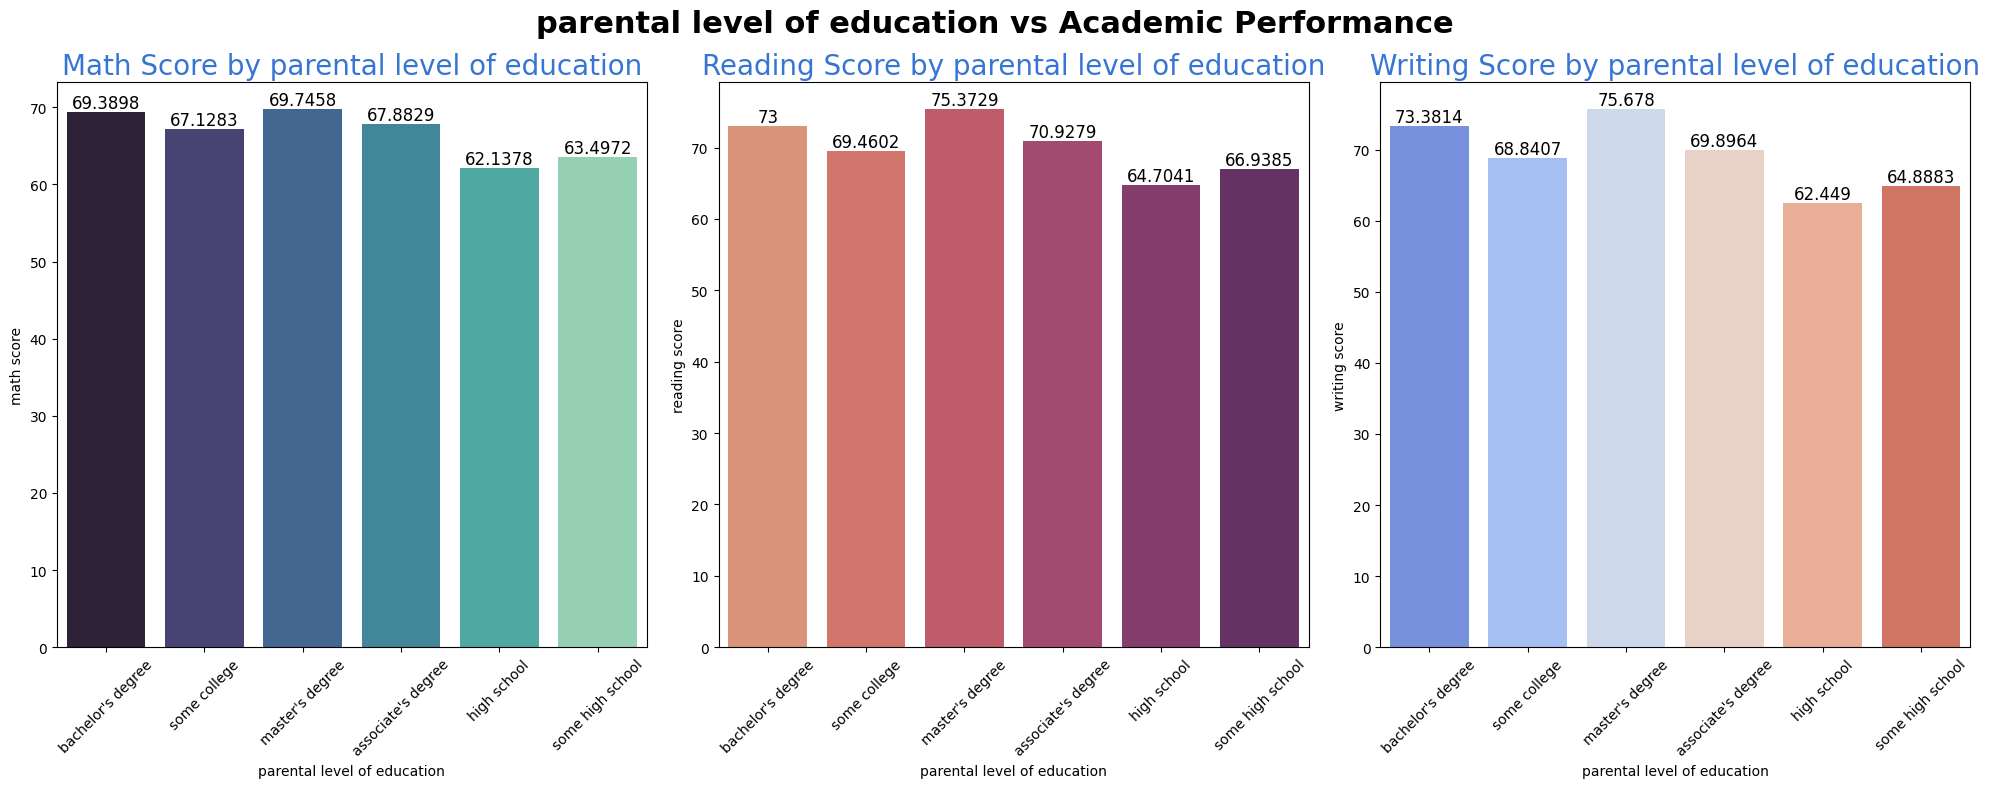

In [73]:
fig, axs = plt.subplots(1,3, figsize=(20,8))

sns.barplot(data=df, x="parental level of education", y = "math score", palette='mako', errorbar=None, ax=axs[0])
axs[0].set_title("Math Score by parental level of education", color="#3775d2", size=20)
axs[0].tick_params(axis='x', rotation=45)
for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=12)

sns.barplot(data=df, x="parental level of education", y = "reading score", palette='flare', errorbar=None, ax=axs[1])
axs[1].set_title("Reading Score by parental level of education", color="#3775d2", size=20)
axs[1].tick_params(axis='x', rotation=45)
for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=12)

sns.barplot(data=df, x="parental level of education", y = "writing score", palette='coolwarm', errorbar=None, ax=axs[2])
axs[2].set_title("Writing Score by parental level of education", color="#3775d2", size=20)
axs[2].tick_params(axis='x', rotation=45)
for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=12)

plt.suptitle("parental level of education vs Academic Performance", fontweight='bold', size=22)
plt.tight_layout()
plt.show()

#### 4.4.4 LUNCH COLUMN

- What is the effect of lunch type on test results?


BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

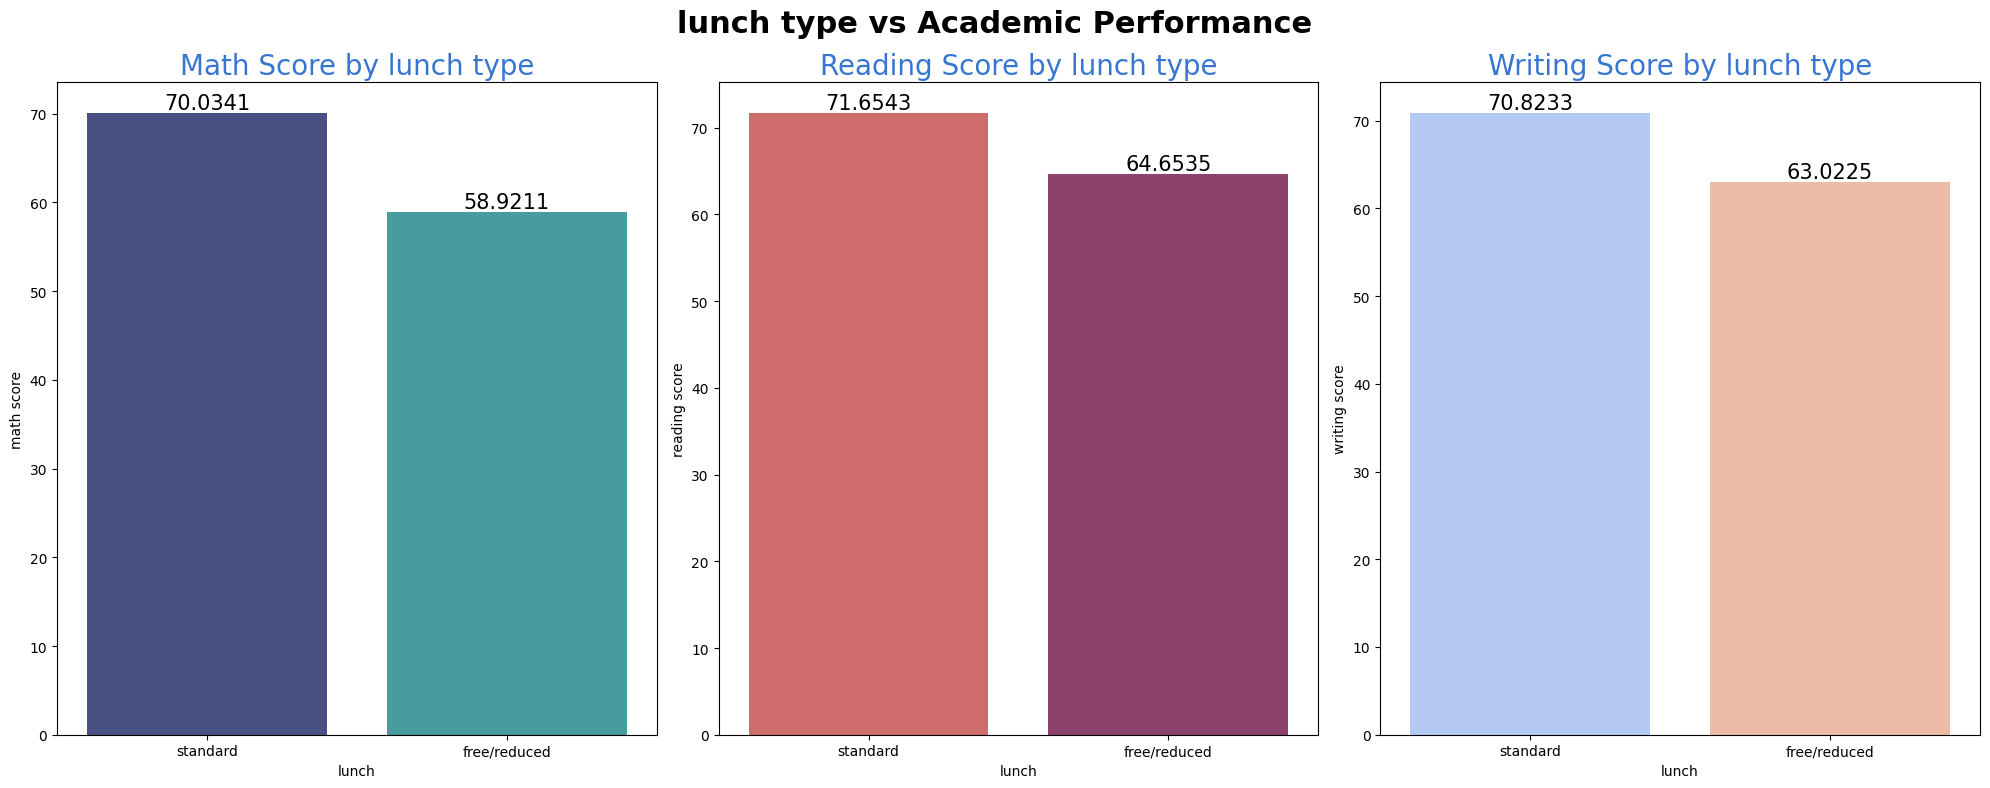

In [76]:
fig, axs = plt.subplots(1,3, figsize=(20,8))

sns.barplot(data=df, x="lunch", y = "math score", palette='mako', errorbar=None, ax=axs[0])
axs[0].set_title("Math Score by lunch type", color="#3775d2", size=20)
for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=15)

sns.barplot(data=df, x="lunch", y = "reading score", palette='flare', errorbar=None, ax=axs[1])
axs[1].set_title("Reading Score by lunch type", color="#3775d2", size=20)
for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=15)

sns.barplot(data=df, x="lunch", y = "writing score", palette='coolwarm', errorbar=None, ax=axs[2])
axs[2].set_title("Writing Score by lunch type", color="#3775d2", size=20)
for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=15)

plt.suptitle("lunch type vs Academic Performance", fontweight='bold', size=22)
plt.tight_layout()
plt.show()

In [77]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


#### 4.4.5 TEST PREPARATION COURSE COLUMN

- Is Test prepration course has any impact on student's performance ?



BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

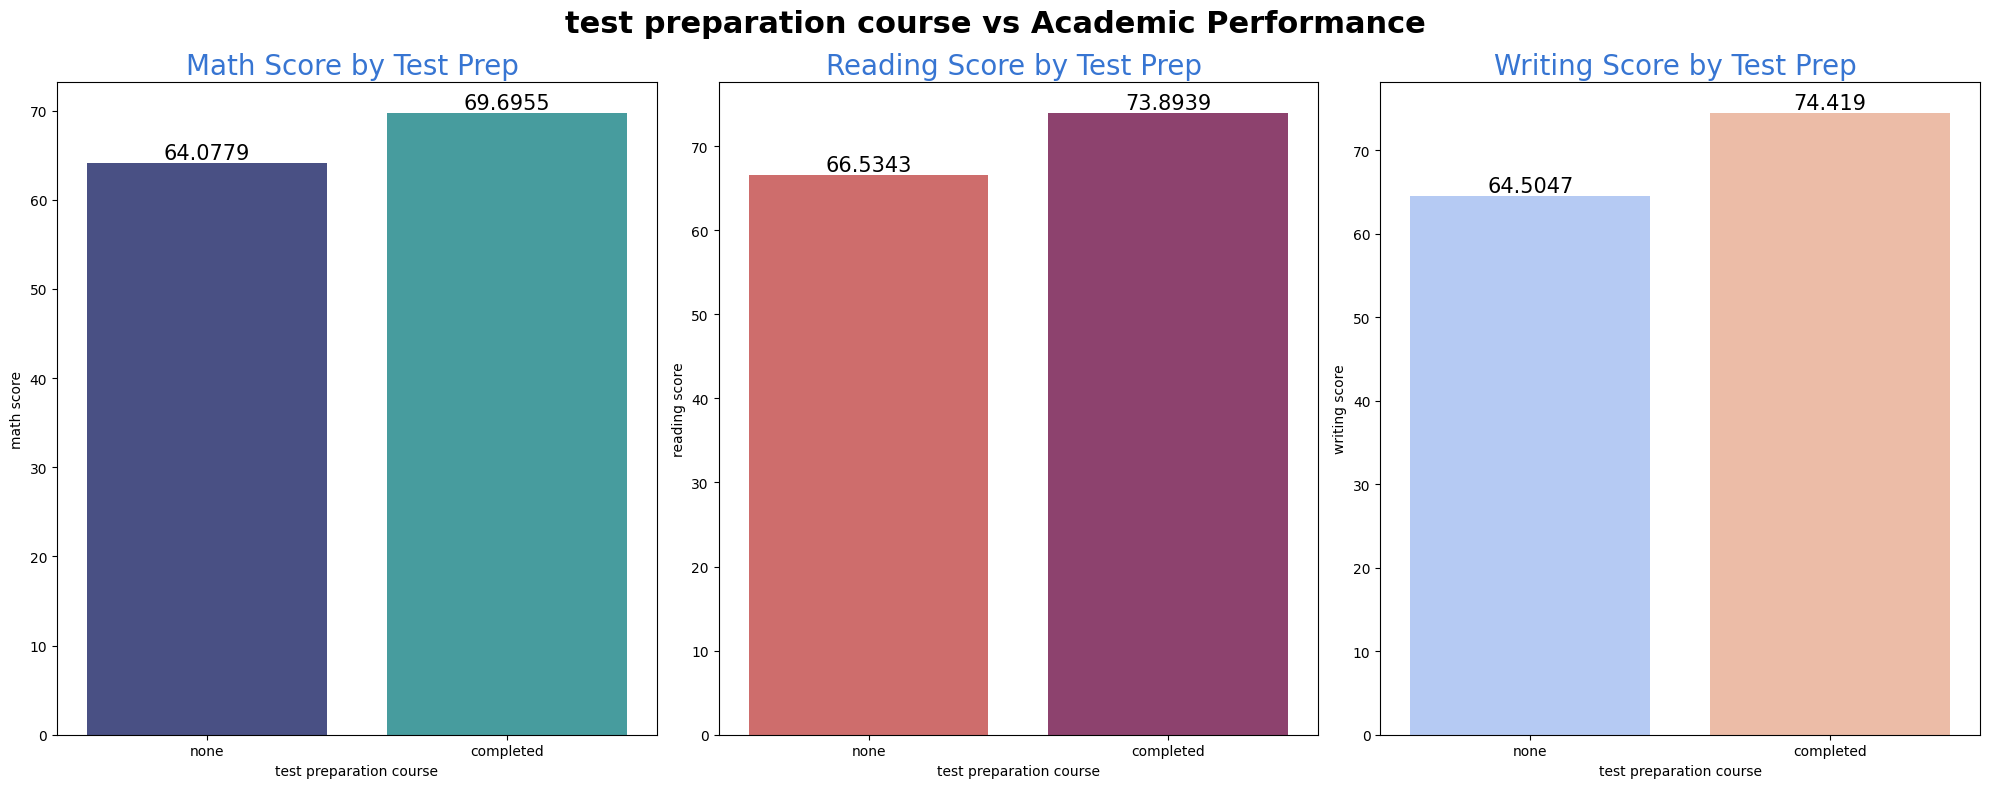

In [78]:
fig, axs = plt.subplots(1,3, figsize=(20,8))

sns.barplot(data=df, x="test preparation course", y = "math score", palette='mako', errorbar=None, ax=axs[0])
axs[0].set_title("Math Score by Test Prep ", color="#3775d2", size=20)
for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=15)

sns.barplot(data=df, x="test preparation course", y = "reading score", palette='flare', errorbar=None, ax=axs[1])
axs[1].set_title("Reading Score by Test Prep ", color="#3775d2", size=20)
for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=15)

sns.barplot(data=df, x="test preparation course", y = "writing score", palette='coolwarm', errorbar=None, ax=axs[2])
axs[2].set_title("Writing Score by Test Prep ", color="#3775d2", size=20)
for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=15)

plt.suptitle("test preparation course vs Academic Performance", fontweight='bold', size=22)
plt.tight_layout()
plt.show()

#### 4.4.6 CHECKING OUTLIERS

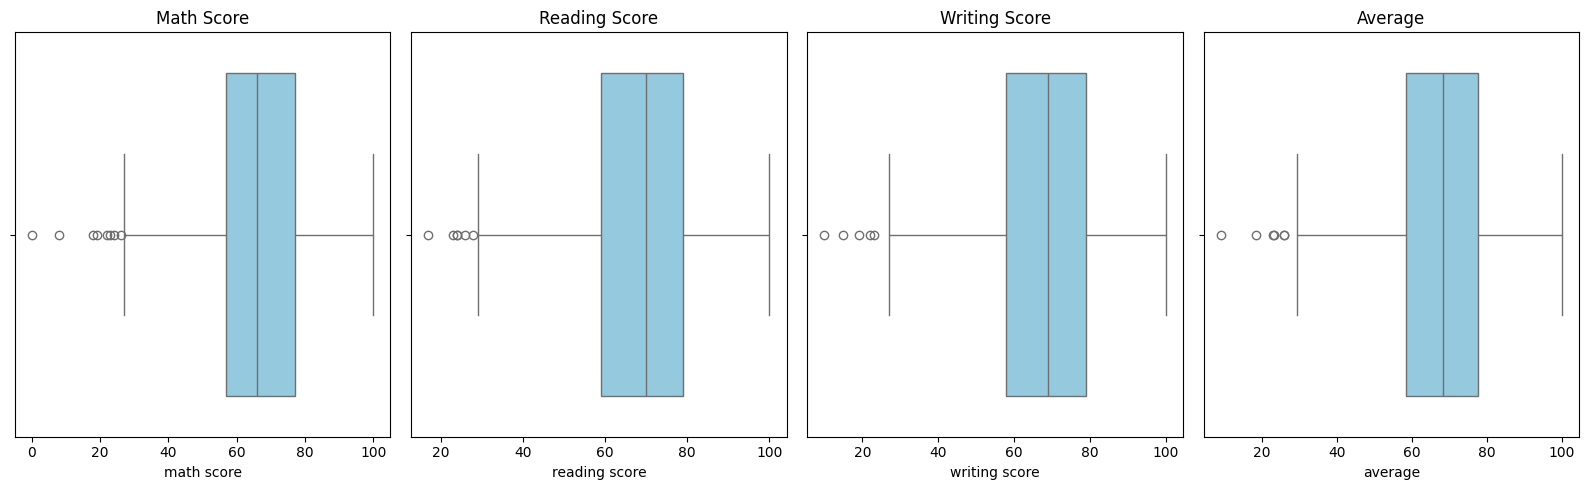

In [84]:
fig, axs = plt.subplots(1, 4, figsize=(16,5))

sns.boxplot(data=df, x= 'math score', color= 'skyblue', ax=axs[0])
axs[0].set_title('Math Score')

sns.boxplot(data=df, x= 'reading score', color= 'skyblue', ax=axs[1])
axs[1].set_title('Reading Score')

sns.boxplot(data=df, x= 'writing score', color= 'skyblue', ax=axs[2])
axs[2].set_title('Writing Score')

sns.boxplot(data=df, x= 'average', color= 'skyblue', ax=axs[3])
axs[3].set_title('Average')

plt.tight_layout()
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

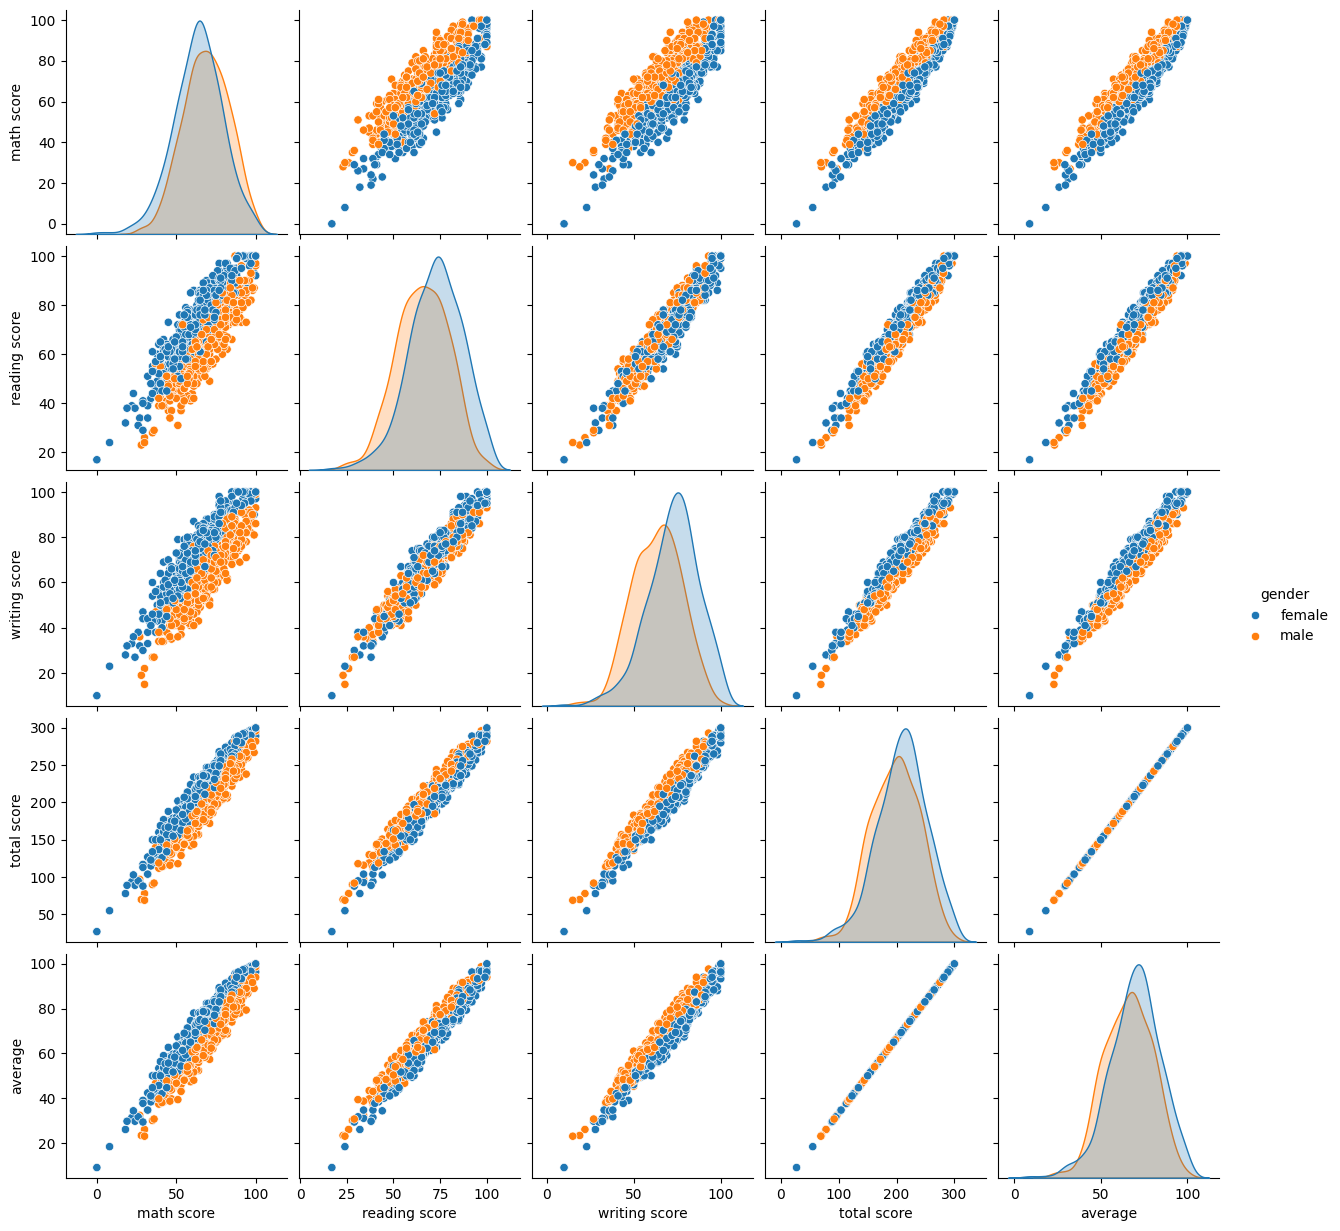

In [86]:
sns.pairplot(df, hue='gender')
plt.show()

### 5. Conclusions

- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.